In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# Stage 5 — Large synthetic TSC benchmark
# Frozen physical benchmark configuration
# ============================================================

N = 50

WS_K = 4
WS_BETA = 0.20

LAMBDA_NONLINEAR = 0.5

N_SNAPSHOTS = 10

EPS_VALUES = np.array([
    .005, .0075, .01, .015,
    .02, .03, .04,
    .06, .08, .10, .12
], dtype=float)

N_TRAIN = 3000
N_TEST = 1000
N_TOTAL = N_TRAIN + N_TEST

SEED_GRAPH = 2026081301
SEED_WEIGHTS = 2026081302
SEED_PROTOCOL = 2026081303
SEED_DATA = 2026081304

RK4_MAX_STEP = 1e-3

print("Stage 5 configuration")
print("---------------------")
print(f"N = {N}")
print(f"WS K = {WS_K}")
print(f"WS beta = {WS_BETA}")
print(f"N snapshots = {N_SNAPSHOTS}")
print(f"N train/test = {N_TRAIN}/{N_TEST}")
print(f"eps = {EPS_VALUES}")

Stage 5 configuration
---------------------
N = 50
WS K = 4
WS beta = 0.2
N snapshots = 10
N train/test = 3000/1000
eps = [0.005  0.0075 0.01   0.015  0.02   0.03   0.04   0.06   0.08   0.1
 0.12  ]


In [2]:
# ============================================================
# Cell 1 — Frozen Watts–Strogatz microscopic network
# ============================================================

from itertools import combinations
import hashlib

assert N > WS_K
assert WS_K % 2 == 0
assert 0.0 <= WS_BETA <= 1.0

G = nx.watts_strogatz_graph(
    n=N,
    k=WS_K,
    p=WS_BETA,
    seed=SEED_GRAPH,
)

# ------------------------------------------------------------
# NetworkX representation: 0-based
# ------------------------------------------------------------

edges_nx = tuple(sorted(
    tuple(sorted((int(i), int(j))))
    for i, j in G.edges()
))

# ------------------------------------------------------------
# TSC / physical representation: 1-based
# ------------------------------------------------------------

edges = tuple(
    (i + 1, j + 1)
    for i, j in edges_nx
)

# ------------------------------------------------------------
# Basic consistency
# ------------------------------------------------------------

assert len(edges) == N * WS_K // 2
assert len(set(edges)) == len(edges)
assert nx.is_connected(G)
assert nx.number_of_selfloops(G) == 0

degrees = np.array([
    G.degree(i)
    for i in range(N)
])

triangles_per_node = np.array([
    nx.triangles(G, i)
    for i in range(N)
])

n_triangles = (
    sum(nx.triangles(G).values()) // 3
)

# ------------------------------------------------------------
# TSC-relevant overlap structure
# ------------------------------------------------------------

centered_wedges = sum(
    d * (d - 1) // 2
    for d in degrees
)

overlap_triads_nx = set()

for e1, e2 in combinations(edges_nx, 2):

    if set(e1) & set(e2):

        support = tuple(
            sorted(set(e1) | set(e2))
        )

        if len(support) == 3:
            overlap_triads_nx.add(support)

overlap_triads = {
    tuple(i + 1 for i in support)
    for support in overlap_triads_nx
}

# ------------------------------------------------------------
# Frozen-realization fingerprint
# ------------------------------------------------------------

graph_hash = hashlib.sha256(
    repr(edges_nx).encode()
).hexdigest()[:12]

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Microscopic WS network")
print("----------------------")

print("N =", G.number_of_nodes())
print("|E| =", G.number_of_edges())

print(
    "mean degree =",
    degrees.mean()
)

print(
    "degree range =",
    (degrees.min(), degrees.max())
)

print(
    "connected =",
    nx.is_connected(G)
)

print(
    "average clustering =",
    nx.average_clustering(G)
)

print(
    "average shortest path length =",
    nx.average_shortest_path_length(G)
)

print(
    "number of triangles =",
    n_triangles
)

print(
    "nodes participating in >=1 triangle =",
    np.sum(triangles_per_node > 0)
)

print(
    "centered overlapping edge pairs =",
    centered_wedges
)

print(
    "unique overlap-induced 3-node supports =",
    len(overlap_triads)
)

print(
    "graph fingerprint =",
    graph_hash
)

Microscopic WS network
----------------------
N = 50
|E| = 100
mean degree = 4.0
degree range = (np.int64(2), np.int64(6))
connected = True
average clustering = 0.33666666666666667
average shortest path length = 3.4089795918367347
number of triangles = 31
nodes participating in >=1 triangle = 46
centered overlapping edge pairs = 319
unique overlap-induced 3-node supports = 257
graph fingerprint = 51e77bf064c6


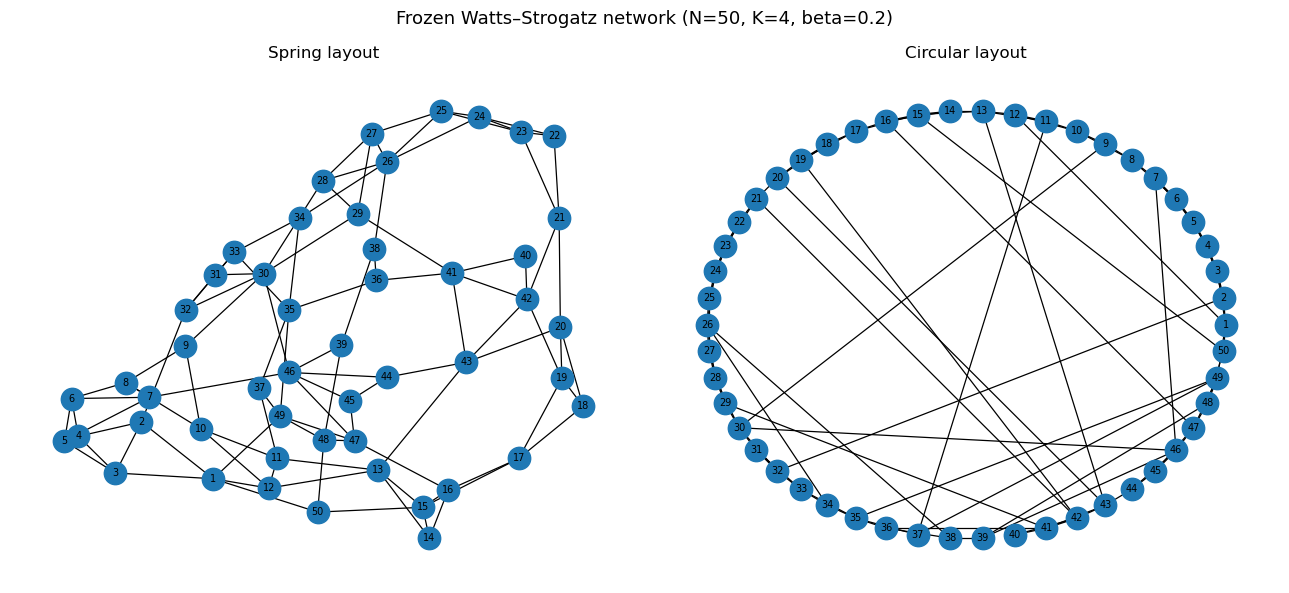

In [3]:
# ============================================================
# Cell 1b — Visualize frozen N=50 Watts–Strogatz network
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 6)
)

# ------------------------------------------------------------
# Left: spring layout
# ------------------------------------------------------------

pos_spring = nx.spring_layout(
    G,
    seed=SEED_GRAPH,
)

nx.draw_networkx(
    G,
    pos=pos_spring,
    ax=axes[0],
    with_labels=True,
    labels={
        i: str(i + 1)
        for i in G.nodes()
    },
    node_size=260,
    font_size=7,
    width=0.9,
)

axes[0].set_title(
    "Spring layout"
)

axes[0].axis("off")


# ------------------------------------------------------------
# Right: circular layout
#
# Useful for seeing the original WS ring structure
# and rewired long-range shortcuts.
# ------------------------------------------------------------

pos_circular = nx.circular_layout(G)

nx.draw_networkx(
    G,
    pos=pos_circular,
    ax=axes[1],
    with_labels=True,
    labels={
        i: str(i + 1)
        for i in G.nodes()
    },
    node_size=260,
    font_size=7,
    width=0.9,
)

axes[1].set_title(
    "Circular layout"
)

axes[1].axis("off")


fig.suptitle(
    (
        f"Frozen Watts–Strogatz network "
        f"(N={N}, K={WS_K}, beta={WS_BETA})"
    ),
    fontsize=13,
)

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# Cell 2 — Frozen heterogeneous weights and random
#          temporal activation protocol
# ============================================================

from collections import Counter
from itertools import combinations

# ------------------------------------------------------------
# Frozen heterogeneous edge weights
# ------------------------------------------------------------

weight_rng = np.random.default_rng(
    SEED_WEIGHTS
)

edge_weight_integer = {
    edge: int(
        weight_rng.integers(800, 1201)
    )
    for edge in edges
}

edge_weight = {
    edge: value / 1000.0
    for edge, value in edge_weight_integer.items()
}


# ------------------------------------------------------------
# Balanced random temporal partition
#
# Every microscopic edge appears exactly once.
# 100 edges / 10 snapshots = 10 edges per snapshot.
# ------------------------------------------------------------

assert len(edges) % N_SNAPSHOTS == 0

EDGES_PER_SNAPSHOT = (
    len(edges) // N_SNAPSHOTS
)

protocol_rng = np.random.default_rng(
    SEED_PROTOCOL
)

permutation = protocol_rng.permutation(
    len(edges)
)

shuffled_edges = [
    edges[i]
    for i in permutation
]

snapshots = tuple(
    tuple(
        shuffled_edges[
            r * EDGES_PER_SNAPSHOT:
            (r + 1) * EDGES_PER_SNAPSHOT
        ]
    )
    for r in range(N_SNAPSHOTS)
)


# ------------------------------------------------------------
# Basic protocol audit
# ------------------------------------------------------------

snapshot_edge_counts = Counter(
    edge
    for snapshot in snapshots
    for edge in snapshot
)

assert len(snapshots) == N_SNAPSHOTS

assert all(
    len(snapshot) == EDGES_PER_SNAPSHOT
    for snapshot in snapshots
)

assert set(snapshot_edge_counts) == set(edges)

assert all(
    snapshot_edge_counts[edge] == 1
    for edge in edges
)


# ------------------------------------------------------------
# Structural-overlap audit
#
# Two pairwise edges can contribute to a first-order temporal
# triadic sector only if they share at least one node.
# ------------------------------------------------------------

edge_to_snapshot = {}

for r, snapshot in enumerate(snapshots):
    for edge in snapshot:
        edge_to_snapshot[edge] = r


n_total_overlaps = 0
n_intra_snapshot_overlaps = 0
n_inter_snapshot_overlaps = 0

intra_snapshot_triads = set()
inter_snapshot_triads = set()

inter_snapshot_overlap_pairs = []


for e1, e2 in combinations(edges, 2):

    shared_nodes = (
        set(e1) & set(e2)
    )

    if not shared_nodes:
        continue

    support = tuple(
        sorted(
            set(e1) | set(e2)
        )
    )

    # Different edges sharing one node
    # should generate a 3-node union.
    if len(support) != 3:
        continue

    n_total_overlaps += 1

    r1 = edge_to_snapshot[e1]
    r2 = edge_to_snapshot[e2]

    if r1 == r2:

        n_intra_snapshot_overlaps += 1
        intra_snapshot_triads.add(
            support
        )

    else:

        n_inter_snapshot_overlaps += 1
        inter_snapshot_triads.add(
            support
        )

        # Store chronology explicitly
        if r1 < r2:
            earlier_edge, later_edge = e1, e2
            earlier_snapshot, later_snapshot = r1, r2
        else:
            earlier_edge, later_edge = e2, e1
            earlier_snapshot, later_snapshot = r2, r1

        inter_snapshot_overlap_pairs.append({
            "support": support,
            "earlier_edge": earlier_edge,
            "later_edge": later_edge,
            "earlier_snapshot": earlier_snapshot + 1,
            "later_snapshot": later_snapshot + 1,
        })


# ------------------------------------------------------------
# Snapshot overlap matrix
#
# Entry (r,s) = number of overlapping microscopic edge pairs
# between snapshots r and s.
# ------------------------------------------------------------

snapshot_overlap_matrix = np.zeros(
    (N_SNAPSHOTS, N_SNAPSHOTS),
    dtype=int,
)

for r in range(N_SNAPSHOTS):
    for s in range(r + 1, N_SNAPSHOTS):

        count = 0

        for e1 in snapshots[r]:
            for e2 in snapshots[s]:

                if set(e1) & set(e2):
                    count += 1

        snapshot_overlap_matrix[r, s] = count
        snapshot_overlap_matrix[s, r] = count


# ------------------------------------------------------------
# Snapshot-level diagnostics
# ------------------------------------------------------------

snapshot_rows = []

for r, snapshot in enumerate(
    snapshots,
    start=1
):

    active_nodes = set()

    for edge in snapshot:
        active_nodes.update(edge)

    internal_overlap_count = 0

    for e1, e2 in combinations(
        snapshot,
        2
    ):
        if set(e1) & set(e2):
            internal_overlap_count += 1

    snapshot_rows.append({
        "snapshot": r,
        "n_edges": len(snapshot),
        "n_active_nodes": len(active_nodes),
        "internal_edge_overlaps":
            internal_overlap_count,
    })


snapshot_ledger = pd.DataFrame(
    snapshot_rows
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Frozen random temporal protocol")
print("--------------------------------")

print(
    "snapshots =",
    len(snapshots)
)

print(
    "edges per snapshot =",
    EDGES_PER_SNAPSHOT
)

print(
    "edge exposure = 1"
)

print()

print(
    "total overlapping edge pairs =",
    n_total_overlaps
)

print(
    "intra-snapshot overlaps =",
    n_intra_snapshot_overlaps
)

print(
    "inter-snapshot overlaps =",
    n_inter_snapshot_overlaps
)

print(
    "inter-snapshot overlap fraction =",
    n_inter_snapshot_overlaps
    / n_total_overlaps
)

print()

print(
    "unique intra-snapshot 3-node supports =",
    len(intra_snapshot_triads)
)

print(
    "unique inter-snapshot 3-node supports =",
    len(inter_snapshot_triads)
)

print()

print("Temporal protocol:")

for r, snapshot in enumerate(
    snapshots,
    start=1
):
    print(
        f"  G{r} = {snapshot}"
    )

print()

display(snapshot_ledger)

print("Snapshot overlap matrix:")
display(
    pd.DataFrame(
        snapshot_overlap_matrix,
        index=[
            f"G{i}"
            for i in range(1, N_SNAPSHOTS + 1)
        ],
        columns=[
            f"G{i}"
            for i in range(1, N_SNAPSHOTS + 1)
        ],
    )
)

Frozen random temporal protocol
--------------------------------
snapshots = 10
edges per snapshot = 10
edge exposure = 1

total overlapping edge pairs = 319
intra-snapshot overlaps = 30
inter-snapshot overlaps = 289
inter-snapshot overlap fraction = 0.9059561128526645

unique intra-snapshot 3-node supports = 30
unique inter-snapshot 3-node supports = 236

Temporal protocol:
  G1 = ((25, 26), (1, 2), (48, 49), (4, 5), (1, 50), (21, 22), (33, 35), (39, 48), (44, 46), (10, 12))
  G2 = ((16, 17), (2, 4), (41, 42), (46, 47), (26, 27), (3, 5), (31, 33), (36, 38), (39, 46), (45, 46))
  G3 = ((5, 6), (2, 3), (36, 41), (17, 18), (7, 46), (33, 34), (3, 4), (20, 21), (24, 25), (20, 43))
  G4 = ((13, 14), (26, 34), (11, 12), (26, 38), (19, 20), (40, 41), (47, 48), (25, 27), (12, 13), (11, 37))
  G5 = ((1, 12), (21, 23), (10, 11), (18, 20), (28, 30), (47, 49), (26, 28), (6, 8), (30, 31), (7, 8))
  G6 = ((22, 23), (11, 13), (15, 50), (8, 10), (5, 7), (48, 50), (38, 39), (35, 49), (29, 41), (23, 24)

,snapshot,n_edges,n_active_nodes,internal_edge_overlaps
0,1,10,18,2
1,2,10,18,3
2,3,10,18,2
3,4,10,16,4
4,5,10,17,3
5,6,10,18,2
6,7,10,17,3
7,8,10,16,5
8,9,10,18,2
9,10,10,17,4


Snapshot overlap matrix:


,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10
G1,0,9,7,7,7,10,6,5,3,6
G2,9,0,12,6,3,4,4,9,9,4
G3,7,12,0,5,6,4,5,8,4,6
G4,7,6,5,0,8,7,4,4,7,6
G5,7,3,6,8,0,8,10,10,2,7
G6,10,4,4,7,8,0,9,3,5,6
G7,6,4,5,4,10,9,0,6,6,4
G8,5,9,8,4,10,3,6,0,11,6
G9,3,9,4,7,2,5,6,11,0,11
G10,6,4,6,6,7,6,4,6,11,0


In [5]:
# ============================================================
# Cell 3 — Microscopic nonlinear pairwise vector fields
#
# Purely pairwise WS dynamics:
#
#     phi(x) = x + lambda x^2
#     lambda = 0.5
#
# For edge e = (i,j):
#
#     F_i^e = w_e [phi(x_j) - phi(x_i)]
#     F_j^e = -F_i^e
#
# All other components are zero.
#
# Node labels in `edges` are 1-based.
# Array indices are 0-based internally.
# ============================================================


# ------------------------------------------------------------
# Nonlinear interaction
# ------------------------------------------------------------

def phi_numeric(z):
    return (
        z
        + LAMBDA_NONLINEAR * z**2
    )


# ------------------------------------------------------------
# Single-edge microscopic vector field
# ------------------------------------------------------------

def edge_field_numeric(X, edge):
    """
    Evaluate one conservative nonlinear pairwise edge field.

    Parameters
    ----------
    X : ndarray, shape (..., N)
        One state or an arbitrary batch of states.

    edge : tuple[int, int]
        1-based node labels, e.g. (1, 2).

    Returns
    -------
    F : ndarray, same shape as X

    Dynamics
    --------
    For edge (i,j):

        F_i = w_ij [phi(x_j) - phi(x_i)]
        F_j = -F_i
    """

    i, j = edge

    if edge not in edge_weight:
        raise KeyError(
            f"Unknown microscopic edge: {edge}"
        )

    # Convert physical 1-based labels
    # to NumPy 0-based indices.
    ii = i - 1
    jj = j - 1

    w = edge_weight[edge]

    F = np.zeros_like(
        X,
        dtype=float
    )

    interaction = w * (
        phi_numeric(X[..., jj])
        -
        phi_numeric(X[..., ii])
    )

    F[..., ii] += interaction
    F[..., jj] -= interaction

    return F


# ------------------------------------------------------------
# Snapshot vector field
#
# Each snapshot contains exactly 10 simultaneously active
# pairwise microscopic edges.
# ------------------------------------------------------------

def snapshot_field_numeric(
    X,
    snapshot_index,
):
    """
    Evaluate one complete snapshot generator.

    Parameters
    ----------
    X : ndarray, shape (..., N)

    snapshot_index : int
        Python index 0,...,N_SNAPSHOTS-1.

    Returns
    -------
    F : ndarray, same shape as X
    """

    if not (
        0 <= snapshot_index < N_SNAPSHOTS
    ):
        raise IndexError(
            "snapshot_index out of range."
        )

    snapshot = snapshots[
        snapshot_index
    ]

    F = np.zeros_like(
        X,
        dtype=float
    )

    for edge in snapshot:

        F += edge_field_numeric(
            X,
            edge
        )

    return F


# ------------------------------------------------------------
# Full microscopic aggregate field
#
# Useful only as an exact zeroth-order reference:
#
#     F^(0) = (1 / N_SNAPSHOTS) * sum_e F_e
#
# because every microscopic edge appears exactly once.
# ------------------------------------------------------------

def full_pairwise_field_numeric(X):
    """
    Sum all 100 microscopic pairwise edge fields.
    """

    F = np.zeros_like(
        X,
        dtype=float
    )

    for edge in edges:

        F += edge_field_numeric(
            X,
            edge
        )

    return F


def F0_oracle_numeric(X):
    """
    Exact zeroth-order effective generator.

        F^(0) = (1 / 10) sum_e F_e
    """

    return (
        full_pairwise_field_numeric(X)
        /
        N_SNAPSHOTS
    )


# ------------------------------------------------------------
# Physical consistency audit
# ------------------------------------------------------------

audit_rng = np.random.default_rng(
    SEED_DATA + 101
)

X_check = audit_rng.uniform(
    -0.5,
    0.5,
    size=(64, N)
)


# ------------------------------------------------------------
# 1. Single-edge fields
# ------------------------------------------------------------

max_edge_conservation_error = 0.0

for edge in edges:

    F_check = edge_field_numeric(
        X_check,
        edge
    )

    assert (
        F_check.shape
        ==
        X_check.shape
    )

    error = np.max(
        np.abs(
            F_check.sum(axis=1)
        )
    )

    max_edge_conservation_error = max(
        max_edge_conservation_error,
        error
    )


# ------------------------------------------------------------
# 2. Snapshot fields
# ------------------------------------------------------------

max_snapshot_conservation_error = 0.0

for r in range(N_SNAPSHOTS):

    F_check = snapshot_field_numeric(
        X_check,
        r
    )

    assert (
        F_check.shape
        ==
        X_check.shape
    )

    error = np.max(
        np.abs(
            F_check.sum(axis=1)
        )
    )

    max_snapshot_conservation_error = max(
        max_snapshot_conservation_error,
        error
    )


# ------------------------------------------------------------
# 3. Zeroth-order identity
#
# Average over snapshot generators must equal
# the full microscopic field divided by 10.
# ------------------------------------------------------------

snapshot_average = np.zeros_like(
    X_check,
    dtype=float
)

for r in range(N_SNAPSHOTS):

    snapshot_average += (
        snapshot_field_numeric(
            X_check,
            r
        )
    )

snapshot_average /= N_SNAPSHOTS


F0_check = F0_oracle_numeric(
    X_check
)

F0_identity_error = np.max(
    np.abs(
        snapshot_average
        -
        F0_check
    )
)


# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert (
    max_edge_conservation_error
    < 1e-13
)

assert (
    max_snapshot_conservation_error
    < 1e-13
)

assert (
    F0_identity_error
    < 1e-13
)


# ------------------------------------------------------------
# Scale diagnostics
# ------------------------------------------------------------

snapshot_rms = []

for r in range(N_SNAPSHOTS):

    F_check = snapshot_field_numeric(
        X_check,
        r
    )

    snapshot_rms.append(
        np.sqrt(
            np.mean(
                F_check**2
            )
        )
    )

snapshot_rms = np.asarray(
    snapshot_rms
)

F0_rms = np.sqrt(
    np.mean(
        F0_check**2
    )
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print(
    "Microscopic nonlinear WS dynamics initialized."
)

print(
    "  pairwise microscopic edges =",
    len(edges)
)

print(
    "  nonlinear lambda =",
    LAMBDA_NONLINEAR
)

print(
    "  native higher-order interactions = 0"
)

print(
    "  snapshots =",
    N_SNAPSHOTS
)

print(
    "  edges / snapshot =",
    EDGES_PER_SNAPSHOT
)

print()

print(
    "Physical consistency:"
)

print(
    "  max edge conservation error =",
    f"{max_edge_conservation_error:.3e}"
)

print(
    "  max snapshot conservation error =",
    f"{max_snapshot_conservation_error:.3e}"
)

print(
    "  F0 snapshot-average identity error =",
    f"{F0_identity_error:.3e}"
)

print()

print(
    "Field-scale diagnostics:"
)

print(
    "  snapshot RMS range =",
    (
        float(snapshot_rms.min()),
        float(snapshot_rms.max()),
    )
)

print(
    "  exact F^(0) RMS =",
    float(F0_rms)
)

Microscopic nonlinear WS dynamics initialized.
  pairwise microscopic edges = 100
  nonlinear lambda = 0.5
  native higher-order interactions = 0
  snapshots = 10
  edges / snapshot = 10

Physical consistency:
  max edge conservation error = 0.000e+00
  max snapshot conservation error = 6.436e-16
  F0 snapshot-average identity error = 1.110e-16

Field-scale diagnostics:
  snapshot RMS range = (0.2475275490297667, 0.3088592564064006)
  exact F^(0) RMS = 0.1323923932040961


In [6]:
# ============================================================
# Cell 4 — Exact sparse polynomial oracle for F^(0) and F^(1)
#
# No SymPy expansion is used.
#
# Each polynomial is represented sparsely:
#
#     monomial tuple -> exact rational coefficient
#
# Examples:
#
#     (3,)      -> x3
#     (3, 3)   -> x3^2
#     (2, 5)   -> x2*x5
#
# Exact Fraction arithmetic guarantees that structural zeros
# caused by cancellation are identified exactly.
# ============================================================

from fractions import Fraction
from collections import Counter


# ------------------------------------------------------------
# Frozen exact nonlinear coefficient
# ------------------------------------------------------------

assert np.isclose(
    LAMBDA_NONLINEAR,
    0.5
)

LAMBDA_EXACT = Fraction(1, 2)


# ============================================================
# Sparse polynomial / vector-field utilities
# ============================================================

def zero_sparse_field():
    """
    Return a zero N-component sparse polynomial vector field.
    """
    return [
        {}
        for _ in range(N)
    ]


def add_term(
    poly,
    monomial,
    coefficient,
):
    """
    Add one exact coefficient to a sparse polynomial.
    """

    coefficient = Fraction(
        coefficient
    )

    if coefficient == 0:
        return

    monomial = tuple(
        sorted(monomial)
    )

    new_value = (
        poly.get(
            monomial,
            Fraction(0)
        )
        +
        coefficient
    )

    if new_value == 0:
        poly.pop(
            monomial,
            None
        )
    else:
        poly[monomial] = new_value


def add_field_scaled(
    target,
    source,
    scale=Fraction(1),
):
    """
    target += scale * source
    """

    scale = Fraction(scale)

    for output in range(N):

        for monomial, coefficient in (
            source[output].items()
        ):

            add_term(
                target[output],
                monomial,
                scale * coefficient,
            )


def scale_field(
    field,
    scale,
):
    """
    Return scale * field.
    """

    out = zero_sparse_field()

    add_field_scaled(
        out,
        field,
        scale=scale,
    )

    return out


# ============================================================
# Exact microscopic edge fields
# ============================================================

def edge_field_exact(edge):
    """
    Exact sparse polynomial representation of one edge field.

    For e=(i,j):

        F_i = w [x_j - x_i
                 + lambda (x_j^2 - x_i^2)]

        F_j = -F_i
    """

    i, j = edge

    w = Fraction(
        int(
            edge_weight_integer[edge]
        ),
        1000,
    )

    field = zero_sparse_field()

    ii = i - 1
    jj = j - 1

    # --------------------------------------------------------
    # Output i
    # --------------------------------------------------------

    add_term(
        field[ii],
        (j,),
        +w,
    )

    add_term(
        field[ii],
        (i,),
        -w,
    )

    add_term(
        field[ii],
        (j, j),
        +w * LAMBDA_EXACT,
    )

    add_term(
        field[ii],
        (i, i),
        -w * LAMBDA_EXACT,
    )

    # --------------------------------------------------------
    # Output j = negative of output i
    # --------------------------------------------------------

    add_term(
        field[jj],
        (j,),
        -w,
    )

    add_term(
        field[jj],
        (i,),
        +w,
    )

    add_term(
        field[jj],
        (j, j),
        -w * LAMBDA_EXACT,
    )

    add_term(
        field[jj],
        (i, i),
        +w * LAMBDA_EXACT,
    )

    return field


edge_fields_exact = {
    edge: edge_field_exact(edge)
    for edge in edges
}


# ============================================================
# Exact snapshot generators
# ============================================================

snapshot_fields_exact = []

for snapshot in snapshots:

    field = zero_sparse_field()

    for edge in snapshot:

        add_field_scaled(
            field,
            edge_fields_exact[edge],
        )

    snapshot_fields_exact.append(
        field
    )


assert (
    len(snapshot_fields_exact)
    ==
    N_SNAPSHOTS
)


# ============================================================
# Sparse directional derivative
#
#     J_target(x) @ direction(x)
#
# Both target and direction are sparse polynomial fields.
# ============================================================

def directional_derivative(
    target,
    direction,
):
    """
    Compute

        J_target(x) @ direction(x)

    exactly in sparse polynomial form.
    """

    out = zero_sparse_field()

    for output in range(N):

        # One monomial of target_output
        for monomial, coefficient in (
            target[output].items()
        ):

            # Variables appearing in this monomial
            variable_counts = Counter(
                monomial
            )

            for variable, power in (
                variable_counts.items()
            ):

                # ------------------------------------------------
                # derivative of monomial w.r.t. x_variable
                # ------------------------------------------------

                remaining = list(
                    monomial
                )

                remaining.remove(
                    variable
                )

                derivative_monomial = tuple(
                    remaining
                )

                derivative_coefficient = (
                    coefficient
                    *
                    power
                )

                # direction component for this variable
                direction_component = (
                    direction[
                        variable - 1
                    ]
                )

                for (
                    direction_monomial,
                    direction_coefficient,
                ) in direction_component.items():

                    product_monomial = tuple(
                        sorted(
                            derivative_monomial
                            +
                            direction_monomial
                        )
                    )

                    add_term(
                        out[output],
                        product_monomial,
                        (
                            derivative_coefficient
                            *
                            direction_coefficient
                        ),
                    )

    return out


# ============================================================
# Exact vector-field Lie bracket
#
# Convention:
#
#     [F,G] = J_G F - J_F G
#
# This is the same convention used in the N=8 oracle audit.
# ============================================================

def lie_bracket_exact(
    F,
    G,
):
    JG_F = directional_derivative(
        G,
        F,
    )

    JF_G = directional_derivative(
        F,
        G,
    )

    bracket = zero_sparse_field()

    add_field_scaled(
        bracket,
        JG_F,
        +1,
    )

    add_field_scaled(
        bracket,
        JF_G,
        -1,
    )

    return bracket


# ============================================================
# Exact F^(0)
#
# Every snapshot lasts epsilon / 10.
# Every microscopic edge appears exactly once.
# ============================================================

F0_oracle_exact = zero_sparse_field()

for field in snapshot_fields_exact:

    add_field_scaled(
        F0_oracle_exact,
        field,
        Fraction(
            1,
            N_SNAPSHOTS
        ),
    )


# ============================================================
# Exact F^(1)
#
# For chronological protocol
#
#     G1 -> G2 -> ... -> G10
#
# and equal snapshot duration epsilon / m:
#
#     F^(1)
#       = 1/(2 m^2)
#         sum_{s>r} [G_r, G_s]
#
# ============================================================

F1_oracle_exact = zero_sparse_field()

n_snapshot_brackets = 0

for r in range(N_SNAPSHOTS):

    for s in range(
        r + 1,
        N_SNAPSHOTS
    ):

        bracket = lie_bracket_exact(
            snapshot_fields_exact[r],
            snapshot_fields_exact[s],
        )

        add_field_scaled(
            F1_oracle_exact,
            bracket,
        )

        n_snapshot_brackets += 1


F1_oracle_exact = scale_field(
    F1_oracle_exact,
    Fraction(
        1,
        2 * N_SNAPSHOTS**2
    ),
)


assert (
    n_snapshot_brackets
    ==
    N_SNAPSHOTS
    * (N_SNAPSHOTS - 1)
    // 2
)


# ============================================================
# Structural-support extraction
#
# Minimal support:
#
#     S = {output node}
#         union
#         {variables appearing in monomial}
# ============================================================

def sparse_field_supports(field):

    supports = set()

    for output, poly in enumerate(
        field,
        start=1,
    ):

        for monomial, coefficient in (
            poly.items()
        ):

            if coefficient == 0:
                continue

            support = tuple(
                sorted(
                    set(monomial)
                    |
                    {output}
                )
            )

            supports.add(
                support
            )

    return tuple(
        sorted(
            supports,
            key=lambda s: (
                len(s),
                s,
            )
        )
    )


F0_oracle_supports = (
    sparse_field_supports(
        F0_oracle_exact
    )
)

F1_oracle_supports = (
    sparse_field_supports(
        F1_oracle_exact
    )
)


# ============================================================
# Polynomial-degree diagnostics
# ============================================================

def field_degree_counts(field):

    counts = Counter()

    for poly in field:

        for monomial, coefficient in (
            poly.items()
        ):

            if coefficient != 0:

                counts[
                    len(monomial)
                ] += 1

    return dict(
        sorted(
            counts.items()
        )
    )


def support_order_counts(
    supports,
):

    return dict(
        sorted(
            Counter(
                len(s)
                for s in supports
            ).items()
        )
    )


# ============================================================
# Exact F^(0) structural audit
#
# Pure pairwise microscopic dynamics implies:
#
#     singleton supports = all 50 nodes
#     pair supports      = exactly the 100 WS edges
# ============================================================

F0_support_set = set(
    F0_oracle_supports
)

F0_singletons = {
    s
    for s in F0_support_set
    if len(s) == 1
}

F0_pairs = {
    s
    for s in F0_support_set
    if len(s) == 2
}


assert F0_singletons == {
    (i,)
    for i in range(
        1,
        N + 1
    )
}

assert F0_pairs == set(
    edges
)

assert all(
    len(s) <= 2
    for s in F0_support_set
)


# ============================================================
# Exact F^(1) triadic audit
# ============================================================

F1_support_set = set(
    F1_oracle_supports
)

F1_triads = {
    s
    for s in F1_support_set
    if len(s) == 3
}

accessible_triads = set(
    inter_snapshot_triads
)

surviving_accessible_triads = (
    F1_triads
    &
    accessible_triads
)

extinguished_accessible_triads = (
    accessible_triads
    -
    F1_triads
)

unexpected_triads = (
    F1_triads
    -
    accessible_triads
)


# Pair-pair first-order closure cannot exceed 3 nodes.
assert all(
    len(s) <= 3
    for s in F1_support_set
)

# Any exact triadic sector must come from an
# inter-snapshot overlapping pair.
assert len(
    unexpected_triads
) == 0


# ============================================================
# Numerical evaluator for later oracle comparisons
# ============================================================

def evaluate_sparse_field(
    X,
    field,
):
    """
    Evaluate an exact sparse polynomial vector field numerically.

    Parameters
    ----------
    X : ndarray, shape (..., N)

    field : sparse exact field

    Returns
    -------
    Y : ndarray, same shape as X
    """

    X = np.asarray(
        X,
        dtype=float
    )

    Y = np.zeros_like(
        X,
        dtype=float
    )

    for output, poly in enumerate(
        field
    ):

        for monomial, coefficient in (
            poly.items()
        ):

            value = np.ones(
                X.shape[:-1],
                dtype=float,
            )

            for variable in monomial:

                value *= X[
                    ...,
                    variable - 1
                ]

            Y[
                ...,
                output
            ] += (
                float(coefficient)
                *
                value
            )

    return Y


def F1_oracle_numeric(X):

    return evaluate_sparse_field(
        X,
        F1_oracle_exact
    )


# ============================================================
# Cross-check F^(0) against Cell 3 implementation
# ============================================================

F0_sparse_check = evaluate_sparse_field(
    X_check,
    F0_oracle_exact,
)

F0_numeric_check = F0_oracle_numeric(
    X_check
)

F0_sparse_numeric_error = np.max(
    np.abs(
        F0_sparse_check
        -
        F0_numeric_check
    )
)

assert (
    F0_sparse_numeric_error
    < 1e-13
)


# ============================================================
# Summary
# ============================================================

print("Exact sparse TSC oracle constructed.")
print("------------------------------------")

print(
    "snapshot Lie brackets =",
    n_snapshot_brackets
)

print()

print("F^(0):")

print(
    "  support counts =",
    support_order_counts(
        F0_oracle_supports
    )
)

print(
    "  total supports =",
    len(F0_oracle_supports)
)

print(
    "  polynomial term counts by degree =",
    field_degree_counts(
        F0_oracle_exact
    )
)

print(
    "  exact WS pair-support recovery =",
    F0_pairs == set(edges)
)

print()

print("F^(1):")

print(
    "  support counts =",
    support_order_counts(
        F1_oracle_supports
    )
)

print(
    "  total supports =",
    len(F1_oracle_supports)
)

print(
    "  polynomial term counts by degree =",
    field_degree_counts(
        F1_oracle_exact
    )
)

print(
    "  maximum structural order =",
    max(
        len(s)
        for s in F1_oracle_supports
    )
)

print()

print(
    "temporally accessible triads =",
    len(accessible_triads)
)

print(
    "surviving exact F^(1) triads =",
    len(
        surviving_accessible_triads
    )
)

print(
    "extinguished accessible triads =",
    len(
        extinguished_accessible_triads
    )
)

print(
    "unexpected F^(1) triads =",
    len(
        unexpected_triads
    )
)

print()

print(
    "F0 sparse/numeric identity error =",
    f"{F0_sparse_numeric_error:.3e}"
)

Exact sparse TSC oracle constructed.
------------------------------------
snapshot Lie brackets = 45

F^(0):
  support counts = {1: 50, 2: 100}
  total supports = 150
  polynomial term counts by degree = {1: 250, 2: 250}
  exact WS pair-support recovery = True

F^(1):
  support counts = {2: 281, 3: 236}
  total supports = 517
  polynomial term counts by degree = {1: 562, 2: 1265, 3: 978}
  maximum structural order = 3

temporally accessible triads = 236
surviving exact F^(1) triads = 236
extinguished accessible triads = 0
unexpected F^(1) triads = 0

F0 sparse/numeric identity error = 1.665e-16


In [7]:
# ============================================================
# Cell 5 — Forward-only multi-resolution endpoint dataset
#
# Observations available to the learner:
#
#     X0
#     XF(epsilon)
#
# Same initial conditions are used at every epsilon.
# No reverse trajectories are generated.
# ============================================================


# ============================================================
# 1. Fast snapshot evaluator
#
# Mathematically identical to snapshot_field_numeric() from
# Cell 3, but avoids constructing one N-dimensional temporary
# field for every microscopic edge.
# ============================================================

snapshot_operator_data = []

for snapshot in snapshots:

    i_idx = np.array(
        [edge[0] - 1 for edge in snapshot],
        dtype=int,
    )

    j_idx = np.array(
        [edge[1] - 1 for edge in snapshot],
        dtype=int,
    )

    weights = np.array(
        [edge_weight[edge] for edge in snapshot],
        dtype=float,
    )

    # Incidence matrix:
    #
    #   +1 at edge source i
    #   -1 at edge target j
    #
    # Shape = (edges_per_snapshot, N)
    incidence = np.zeros(
        (len(snapshot), N),
        dtype=float,
    )

    for a, (ii, jj) in enumerate(
        zip(i_idx, j_idx)
    ):
        incidence[a, ii] = +1.0
        incidence[a, jj] = -1.0

    snapshot_operator_data.append({
        "i": i_idx,
        "j": j_idx,
        "weights": weights,
        "incidence": incidence,
    })


def snapshot_field_fast(
    X,
    snapshot_index,
):
    """
    Vectorized snapshot generator.

    Equivalent to snapshot_field_numeric(), but evaluates all
    10 simultaneously active edges in one matrix operation.
    """

    data = snapshot_operator_data[
        snapshot_index
    ]

    i_idx = data["i"]
    j_idx = data["j"]
    weights = data["weights"]
    incidence = data["incidence"]

    interaction = (
        phi_numeric(X[..., j_idx])
        -
        phi_numeric(X[..., i_idx])
    )

    interaction *= weights

    return (
        interaction
        @ incidence
    )


# ------------------------------------------------------------
# Cross-check against Cell 3 implementation
# ------------------------------------------------------------

fast_check_rng = np.random.default_rng(
    SEED_DATA + 501
)

X_fast_check = fast_check_rng.uniform(
    -0.5,
    0.5,
    size=(64, N),
)

max_fast_field_error = 0.0

for r in range(N_SNAPSHOTS):

    F_reference = snapshot_field_numeric(
        X_fast_check,
        r,
    )

    F_fast = snapshot_field_fast(
        X_fast_check,
        r,
    )

    max_fast_field_error = max(
        max_fast_field_error,
        float(
            np.max(
                np.abs(
                    F_reference
                    -
                    F_fast
                )
            )
        ),
    )

assert max_fast_field_error < 1e-13

print(
    "Fast snapshot evaluator cross-check:",
    f"{max_fast_field_error:.3e}"
)


# ============================================================
# 2. Vectorized fixed-step RK4
# ============================================================

def rk4_integrate_snapshot(
    X,
    snapshot_index,
    duration,
    max_step=RK4_MAX_STEP,
):
    """
    Integrate one snapshot generator for a fixed duration.

    Parameters
    ----------
    X : ndarray, shape (n_samples, N)

    snapshot_index : int
        Python index 0,...,N_SNAPSHOTS-1.

    duration : float
        Physical duration of this snapshot.

    max_step : float
        Maximum RK4 step.
    """

    n_steps = max(
        1,
        int(
            np.ceil(
                duration
                /
                max_step
            )
        ),
    )

    dt = (
        duration
        /
        n_steps
    )

    Y = np.array(
        X,
        dtype=float,
        copy=True,
    )

    for _ in range(n_steps):

        k1 = snapshot_field_fast(
            Y,
            snapshot_index,
        )

        k2 = snapshot_field_fast(
            Y + 0.5 * dt * k1,
            snapshot_index,
        )

        k3 = snapshot_field_fast(
            Y + 0.5 * dt * k2,
            snapshot_index,
        )

        k4 = snapshot_field_fast(
            Y + dt * k3,
            snapshot_index,
        )

        Y += (
            dt / 6.0
        ) * (
            k1
            + 2.0 * k2
            + 2.0 * k3
            + k4
        )

    return Y


# ============================================================
# 3. Forward chronological protocol
#
#     G1 -> G2 -> ... -> G10
#
# Full aggregation-window duration = epsilon.
# Each snapshot lasts epsilon / 10.
# ============================================================

def forward_protocol(
    X_initial,
    epsilon,
):
    """
    Apply the frozen ten-snapshot temporal protocol.
    """

    Y = np.array(
        X_initial,
        dtype=float,
        copy=True,
    )

    snapshot_duration = (
        float(epsilon)
        /
        N_SNAPSHOTS
    )

    for snapshot_index in range(
        N_SNAPSHOTS
    ):

        Y = rk4_integrate_snapshot(
            Y,
            snapshot_index,
            snapshot_duration,
        )

    return Y


# ============================================================
# 4. Frozen initial conditions
#
# Reinitialize explicitly so previous diagnostic random draws
# cannot alter the formal Stage-5 dataset.
# ============================================================

dataset_rng = np.random.default_rng(
    SEED_DATA
)

X0 = dataset_rng.uniform(
    -0.5,
    0.5,
    size=(N_TOTAL, N),
)

X0_train = X0[:N_TRAIN].copy()
X0_test = X0[N_TRAIN:].copy()


assert X0.shape == (
    N_TOTAL,
    N,
)

assert X0_train.shape == (
    N_TRAIN,
    N,
)

assert X0_test.shape == (
    N_TEST,
    N,
)


# ============================================================
# 5. Exact F^(0) reference at the observed initial states
#
# Used only for benchmark diagnostics.
# Not exposed to the learner.
# ============================================================

F0_X0_oracle = F0_oracle_numeric(
    X0
)

F0_X0_norm = max(
    float(
        np.linalg.norm(
            F0_X0_oracle
        )
    ),
    np.finfo(float).tiny,
)


# ============================================================
# 6. Generate forward-only endpoint observations
#
# Store only train/test endpoint dictionaries rather than
# duplicating a full forward_data dictionary.
# ============================================================

forward_train = {}
forward_test = {}

generation_rows = []

initial_mass = X0.sum(
    axis=1
)


for epsilon in EPS_VALUES:

    epsilon = float(
        epsilon
    )

    XF = forward_protocol(
        X0,
        epsilon,
    )

    assert np.all(
        np.isfinite(XF)
    )

    # --------------------------------------------------------
    # Formal train / test observations
    # --------------------------------------------------------

    forward_train[epsilon] = (
        XF[:N_TRAIN].copy()
    )

    forward_test[epsilon] = (
        XF[N_TRAIN:].copy()
    )


    # --------------------------------------------------------
    # Conservation diagnostic
    # --------------------------------------------------------

    mass_error = np.max(
        np.abs(
            XF.sum(axis=1)
            -
            initial_mass
        )
    )


    # --------------------------------------------------------
    # Endpoint displacement scale
    # --------------------------------------------------------

    displacement_rms = np.sqrt(
        np.mean(
            (XF - X0) ** 2
        )
    )


    # --------------------------------------------------------
    # Zeroth-order secant diagnostic
    #
    #     (XF - X0) / epsilon
    #
    # should approach exact F^(0)(X0) as epsilon -> 0.
    #
    # This is an oracle benchmark diagnostic only.
    # --------------------------------------------------------

    secant_field = (
        XF - X0
    ) / epsilon

    secant_F0_relative_error = (
        np.linalg.norm(
            secant_field
            -
            F0_X0_oracle
        )
        /
        F0_X0_norm
    )


    # --------------------------------------------------------
    # RK4 bookkeeping
    # --------------------------------------------------------

    snapshot_duration = (
        epsilon
        /
        N_SNAPSHOTS
    )

    steps_per_snapshot = max(
        1,
        int(
            np.ceil(
                snapshot_duration
                /
                RK4_MAX_STEP
            )
        ),
    )


    generation_rows.append({

        "epsilon":
            epsilon,

        "steps_per_snapshot":
            steps_per_snapshot,

        "total_RK4_steps":
            steps_per_snapshot
            * N_SNAPSHOTS,

        "displacement_rms":
            float(
                displacement_rms
            ),

        "secant_F0_relative_error":
            float(
                secant_F0_relative_error
            ),

        "max_conservation_error":
            float(
                mass_error
            ),

        "state_min":
            float(
                XF.min()
            ),

        "state_max":
            float(
                XF.max()
            ),
    })


    print(
        f"epsilon={epsilon:7.4f} | "
        f"RK4 steps={steps_per_snapshot * N_SNAPSHOTS:3d} | "
        f"disp RMS={displacement_rms:.3e} | "
        f"secant/F0 err={secant_F0_relative_error:.3e} | "
        f"mass err={mass_error:.3e}"
    )


generation_ledger = pd.DataFrame(
    generation_rows
)


# ============================================================
# 7. Formal learner boundary
#
# The inference algorithm is allowed to access only this object.
#
# It receives:
#
#     X0_train / X0_test
#     forward endpoints at each epsilon
#     epsilon values
#
# It receives no:
#
#     WS graph
#     edge weights
#     snapshots
#     oracle supports
#     F0 oracle
#     F1 oracle
# ============================================================

learner_data = {

    "epsilon_values":
        EPS_VALUES.copy(),

    "X0_train":
        X0_train,

    "X0_test":
        X0_test,

    "forward_train":
        forward_train,

    "forward_test":
        forward_test,
}


# ============================================================
# 8. Final dataset audit
# ============================================================

assert (
    len(
        learner_data[
            "forward_train"
        ]
    )
    ==
    len(EPS_VALUES)
)

assert (
    len(
        learner_data[
            "forward_test"
        ]
    )
    ==
    len(EPS_VALUES)
)


for epsilon in EPS_VALUES:

    epsilon = float(
        epsilon
    )

    assert (
        learner_data[
            "forward_train"
        ][epsilon].shape
        ==
        (
            N_TRAIN,
            N,
        )
    )

    assert (
        learner_data[
            "forward_test"
        ][epsilon].shape
        ==
        (
            N_TEST,
            N,
        )
    )


assert (
    generation_ledger[
        "max_conservation_error"
    ].max()
    <
    1e-10
)


# ============================================================
# Summary
# ============================================================

print()
print(
    "Forward-only Stage-5 dataset generated."
)

print(
    "  data seed =",
    SEED_DATA
)

print(
    "  total initial conditions =",
    N_TOTAL
)

print(
    "  train / test =",
    N_TRAIN,
    "/",
    N_TEST
)

print(
    "  resolutions =",
    len(EPS_VALUES)
)

print(
    "  reverse trajectories generated = False"
)

print(
    "  learner has microscopic graph = False"
)

print(
    "  learner has temporal protocol = False"
)

print(
    "  learner has oracle supports = False"
)

print()

display(
    generation_ledger
)

# ============================================================
# 9. Persist frozen learner dataset BEFORE inference
#
# This is the canonical Stage-5 N=50 dataset.
#
# Saved independently of the inference run so that:
#
#   - kernel / server failure does not require regeneration;
#   - F0 checkpoint can be resumed from the identical dataset;
#   - the exact learner dataset has a permanent SHA-256 ID.
# ============================================================

from pathlib import Path
import hashlib
import json
import gzip
import pickle


DATA_DIR = Path(
    "./stage5_ws_n50_data"
)

DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Stack endpoint dictionaries into deterministic arrays
#
# Shape:
#
#   XF_train_stack : (n_eps, N_train, N)
#   XF_test_stack  : (n_eps, N_test,  N)
#
# Ordering follows EPS_VALUES exactly.
# ------------------------------------------------------------

XF_train_stack = np.stack(
    [
        forward_train[float(eps)]
        for eps in EPS_VALUES
    ],
    axis=0,
)

XF_test_stack = np.stack(
    [
        forward_test[float(eps)]
        for eps in EPS_VALUES
    ],
    axis=0,
)


assert XF_train_stack.shape == (
    len(EPS_VALUES),
    N_TRAIN,
    N,
)

assert XF_test_stack.shape == (
    len(EPS_VALUES),
    N_TEST,
    N,
)


# ------------------------------------------------------------
# Save learner dataset
# ------------------------------------------------------------

LEARNER_DATA_FILE = (
    DATA_DIR
    /
    "stage5_ws_n50_learner_data.npz"
)


np.savez_compressed(

    LEARNER_DATA_FILE,

    X0_train=
        np.asarray(
            X0_train,
            dtype=float,
        ),

    XF_train=
        np.asarray(
            XF_train_stack,
            dtype=float,
        ),

    X0_test=
        np.asarray(
            X0_test,
            dtype=float,
        ),

    XF_test=
        np.asarray(
            XF_test_stack,
            dtype=float,
        ),

    epsilon_values=
        np.asarray(
            EPS_VALUES,
            dtype=float,
        ),
)


# ------------------------------------------------------------
# Save generation diagnostics
# ------------------------------------------------------------

GENERATION_LEDGER_FILE = (
    DATA_DIR
    /
    "generation_ledger.csv"
)

generation_ledger.to_csv(
    GENERATION_LEDGER_FILE,
    index=False,
)


# ============================================================
# 10. Semantic SHA-256 of learner arrays
#
# Hashes array name + dtype + shape + raw C-order bytes.
#
# This is independent of NPZ compression metadata.
# ============================================================

def _update_semantic_hash(
    hasher,
    name,
    array,
):

    arr = np.ascontiguousarray(
        np.asarray(array)
    )

    hasher.update(
        name.encode("utf-8")
    )

    hasher.update(
        str(arr.dtype).encode("utf-8")
    )

    hasher.update(
        np.asarray(
            arr.shape,
            dtype=np.int64,
        ).tobytes()
    )

    hasher.update(
        arr.view(
            np.uint8
        ).tobytes()
    )


_dataset_hasher = hashlib.sha256()


for _name, _array in [

    (
        "X0_train",
        X0_train,
    ),

    (
        "XF_train",
        XF_train_stack,
    ),

    (
        "X0_test",
        X0_test,
    ),

    (
        "XF_test",
        XF_test_stack,
    ),

    (
        "epsilon_values",
        EPS_VALUES,
    ),
]:

    _update_semantic_hash(
        _dataset_hasher,
        _name,
        _array,
    )


LEARNER_DATA_SHA256 = (
    _dataset_hasher.hexdigest()
)


# ============================================================
# 11. Dataset manifest
# ============================================================

DATA_MANIFEST = {

    "dataset":
        "Stage-5 N=50 WS forward-only TSC benchmark",

    "learner_data_sha256":
        LEARNER_DATA_SHA256,

    "graph_fingerprint":
        str(graph_hash),

    "N":
        int(N),

    "WS_K":
        int(WS_K),

    "WS_BETA":
        float(WS_BETA),

    "lambda_nonlinear":
        float(LAMBDA_NONLINEAR),

    "n_snapshots":
        int(N_SNAPSHOTS),

    "n_train":
        int(N_TRAIN),

    "n_test":
        int(N_TEST),

    "epsilon_values":
        [
            float(x)
            for x in EPS_VALUES
        ],

    "RK4_max_step":
        float(RK4_MAX_STEP),

    "seed_graph":
        int(SEED_GRAPH),

    "seed_weights":
        int(SEED_WEIGHTS),

    "seed_protocol":
        int(SEED_PROTOCOL),

    "seed_data":
        int(SEED_DATA),
}


DATA_MANIFEST_FILE = (
    DATA_DIR
    /
    "dataset_manifest.json"
)


with open(
    DATA_MANIFEST_FILE,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        DATA_MANIFEST,
        f,
        indent=2,
    )


# ============================================================
# 12. Save benchmark-side context / oracle
#
# IMPORTANT:
#
# This object is NOT supplied to the learner.
#
# It is saved only so that later:
#
#   - support recovery can be evaluated;
#   - interaction-law reconstruction can be tested;
#   - microscopic topology / weights / chronology can be
#     revealed AFTER blind inference;
#   - Cell 1-4 do not need to be rerun for post-analysis.
# ============================================================

BENCHMARK_CONTEXT = {

    "graph_fingerprint":
        str(graph_hash),

    "edges":
        tuple(edges),

    "edge_weight_integer":
        dict(edge_weight_integer),

    "edge_weight":
        dict(edge_weight),

    "snapshots":
        tuple(snapshots),

    "F0_oracle_exact":
        F0_oracle_exact,

    "F1_oracle_exact":
        F1_oracle_exact,

    "F0_oracle_supports":
        tuple(
            F0_oracle_supports
        ),

    "F1_oracle_supports":
        tuple(
            F1_oracle_supports
        ),

    "inter_snapshot_triads":
        tuple(
            sorted(
                inter_snapshot_triads
            )
        ),
}


BENCHMARK_CONTEXT_FILE = (
    DATA_DIR
    /
    "stage5_ws_n50_benchmark_context.pkl.gz"
)


with gzip.open(
    BENCHMARK_CONTEXT_FILE,
    "wb",
) as f:

    pickle.dump(
        BENCHMARK_CONTEXT,
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )


# ============================================================
# 13. Reload sanity check
# ============================================================

with np.load(
    LEARNER_DATA_FILE
) as _reload:

    assert np.array_equal(
        _reload["X0_train"],
        X0_train,
    )

    assert np.array_equal(
        _reload["XF_train"],
        XF_train_stack,
    )

    assert np.array_equal(
        _reload["X0_test"],
        X0_test,
    )

    assert np.array_equal(
        _reload["XF_test"],
        XF_test_stack,
    )

    assert np.array_equal(
        _reload["epsilon_values"],
        EPS_VALUES,
    )


print()
print("=" * 64)
print("Frozen Stage-5 learner dataset persisted")
print("=" * 64)

print(
    "learner data:",
    LEARNER_DATA_FILE.resolve(),
)

print(
    "generation ledger:",
    GENERATION_LEDGER_FILE.resolve(),
)

print(
    "benchmark context:",
    BENCHMARK_CONTEXT_FILE.resolve(),
)

print()

print(
    "graph fingerprint =",
    graph_hash,
)

print(
    "learner-data SHA256 ="
)

print(
    LEARNER_DATA_SHA256
)

print()

print(
    "Dataset reload sanity check: PASS"
)

Fast snapshot evaluator cross-check: 0.000e+00
epsilon= 0.0050 | RK4 steps= 10 | disp RMS=6.578e-04 | secant/F0 err=1.629e-03 | mass err=3.553e-15
epsilon= 0.0075 | RK4 steps= 10 | disp RMS=9.859e-04 | secant/F0 err=2.442e-03 | mass err=1.776e-15
epsilon= 0.0100 | RK4 steps= 10 | disp RMS=1.314e-03 | secant/F0 err=3.254e-03 | mass err=2.665e-15
epsilon= 0.0150 | RK4 steps= 20 | disp RMS=1.967e-03 | secant/F0 err=4.874e-03 | mass err=1.776e-15
epsilon= 0.0200 | RK4 steps= 20 | disp RMS=2.619e-03 | secant/F0 err=6.490e-03 | mass err=1.776e-15
epsilon= 0.0300 | RK4 steps= 30 | disp RMS=3.917e-03 | secant/F0 err=9.708e-03 | mass err=1.998e-15
epsilon= 0.0400 | RK4 steps= 40 | disp RMS=5.207e-03 | secant/F0 err=1.291e-02 | mass err=2.220e-15
epsilon= 0.0600 | RK4 steps= 60 | disp RMS=7.764e-03 | secant/F0 err=1.925e-02 | mass err=1.776e-15
epsilon= 0.0800 | RK4 steps= 80 | disp RMS=1.029e-02 | secant/F0 err=2.553e-02 | mass err=2.220e-15
epsilon= 0.1000 | RK4 steps=100 | disp RMS=1.279e-02 

,epsilon,steps_per_snapshot,total_RK4_steps,displacement_rms,secant_F0_relative_error,max_conservation_error,state_min,state_max
0,0.0050,1,10,0.000658,0.001629,3.552714e-15,-0.499775,0.499425
1,0.0075,1,10,0.000986,0.002442,1.776357e-15,-0.499664,0.499246
2,0.0100,1,10,0.001314,0.003254,2.664535e-15,-0.499553,0.499067
3,0.0150,2,20,0.001967,0.004874,1.776357e-15,-0.499332,0.498709
4,0.0200,2,20,0.002619,0.006490,1.776357e-15,-0.499110,0.498350
5,0.0300,3,30,0.003917,0.009708,1.998401e-15,-0.498703,0.497646
6,0.0400,4,40,0.005207,0.012907,2.220446e-15,-0.498297,0.497136
7,0.0600,6,60,0.007764,0.019253,1.776357e-15,-0.497649,0.496112
8,0.0800,8,80,0.010290,0.025529,2.220446e-15,-0.497415,0.495084
9,0.1000,10,100,0.012786,0.031735,2.220446e-15,-0.497279,0.494052



Frozen Stage-5 learner dataset persisted
learner data: E:\Code\Github_clone\TSC-TemporalStructureClosure\stage5_ws_n50_data\stage5_ws_n50_learner_data.npz
generation ledger: E:\Code\Github_clone\TSC-TemporalStructureClosure\stage5_ws_n50_data\generation_ledger.csv
benchmark context: E:\Code\Github_clone\TSC-TemporalStructureClosure\stage5_ws_n50_data\stage5_ws_n50_benchmark_context.pkl.gz

graph fingerprint = 51e77bf064c6
learner-data SHA256 =
e6b4c45af9bacb0df67d8e44d002f7587e86ed12a3d180a4658a87d8c0a4202a

Dataset reload sanity check: PASS


In [9]:
### Frozen Stage-5 N=50 WS benchmark

# Graph fingerprint:
# `51e77bf064c6`

# Learner-data SHA256:
# `e6b4c45af9bacb0df67d8e44d002f7587e86ed12a3d180a4658a87d8c0a4202a`

# Inference implementation:
# `TSC_AGLASSO v3.1`

In [10]:
# # ============================================================
# # Cell 5.5 — N=50 F0 pre-path timing diagnostic
# #
# # Run BEFORE the formal Cell 6.
# # Does NOT start the regularization path.
# # ============================================================

# import time
# import numpy as np
# from pathlib import Path
# from threadpoolctl import threadpool_info

# import TSC_AGLASSO as tsc


# # ------------------------------------------------------------
# # Load canonical learner dataset
# # ------------------------------------------------------------

# DATA_FILE = Path(
#     "./stage5_ws_n50_data/stage5_ws_n50_learner_data.npz"
# )

# with np.load(DATA_FILE) as data:
#     X0 = np.asarray(data["X0_train"], dtype=float)
#     XF = np.asarray(data["XF_train"], dtype=float)
#     EPS = np.asarray(data["epsilon_values"], dtype=float)


# print("BLAS:")
# for info in threadpool_info():
#     if info.get("user_api") == "blas":
#         print(
#             info.get("internal_api"),
#             "| threads =", info.get("num_threads"),
#             "| version =", info.get("version"),
#         )

# print()


# def run_timed(label, fn):
#     print(f">>> {label}", flush=True)
#     t0 = time.perf_counter()
#     out = fn()
#     dt = time.perf_counter() - t0
#     print(
#         f"<<< {label}: {dt:.3f} s "
#         f"({dt/60:.3f} min)",
#         flush=True,
#     )
#     print()
#     return out, dt


# # ------------------------------------------------------------
# # 1. Endpoint extrapolation
# # ------------------------------------------------------------

# (A_train, G1_train, eps_used), t_extrap = run_timed(
#     "1. endpoint extrapolation",
#     lambda: tsc._resolution_extrapolation(
#         X0,
#         XF,
#         EPS,
#         n_points=4,
#         polynomial_order=3,
#     ),
# )


# # ------------------------------------------------------------
# # 2. Library + Theta
# # ------------------------------------------------------------

# library = tsc.StructuralPolynomialLibrary(
#     n_nodes=50,
#     max_polynomial_degree=3,
#     max_interaction_order=4,
# )

# print("features =", library.n_features)
# print("groups   =", len(library.structural_groups))
# print("all-valid =", bool(np.all(library.valid_mask)))
# print()


# Theta, t_theta = run_timed(
#     "2. Theta construction/scaling",
#     lambda: library.fit_transform(X0),
# )

# print(
#     "Theta:",
#     Theta.shape,
#     f"{Theta.nbytes / 1024**3:.3f} GiB",
# )
# print()


# # ------------------------------------------------------------
# # Exact F0 estimator
# # ------------------------------------------------------------

# est = tsc._AdaptiveGroupLasso(
#     library=library,

#     n_lambdas=80,
#     lambda_min_ratio=1e-6,

#     coarse_n_lambdas=32,
#     refine_n_lambdas=12,

#     gamma=1.0,
#     delta_ratio=1e-8,

#     max_iter=5000,
#     tol=1e-8,
#     active_group_tol=1e-10,

#     ridge_condition_target=1e6,
#     ridge_alpha_floor_ratio=1e-12,

#     kkt_tol=1e-7,
#     max_kkt_expansions=100,

#     verbose=False,
#     label="F0 timing",
# )


# # ------------------------------------------------------------
# # 3. Spectral estimate used by adaptive Ridge
# # ------------------------------------------------------------

# ridge_info, t_spec1 = run_timed(
#     "3. spectral estimate #1",
#     lambda: est._adaptive_ridge_alpha(Theta),
# )

# alpha, spectral_max, spectral_min = ridge_info

# print("ridge alpha =", alpha)
# print("lambda_max  =", spectral_max)
# print()


# # ------------------------------------------------------------
# # 4. Ridge solve only
# # ------------------------------------------------------------

# B_init, t_ridge = run_timed(
#     "4. dual Ridge solve",
#     lambda: est._ridge_solve(
#         Theta,
#         A_train,
#         alpha,
#     ),
# )


# # ------------------------------------------------------------
# # 5. Adaptive weights
# # ------------------------------------------------------------

# weights, t_weights = run_timed(
#     "5. adaptive weights over all groups",
#     lambda: est._adaptive_weights(
#         B_init
#     ),
# )


# # ------------------------------------------------------------
# # 6. Group-LASSO lambda_max
# # ------------------------------------------------------------

# gl_lambda_max, t_glambda = run_timed(
#     "6. Group-LASSO lambda_max",
#     lambda: est._lambda_max(
#         Theta,
#         A_train,
#         weights,
#     ),
# )

# print("Group-LASSO lambda_max =", gl_lambda_max)
# print()


# # ------------------------------------------------------------
# # 7. Second spectral estimate used for Lipschitz
# # ------------------------------------------------------------

# L, t_spec2 = run_timed(
#     "7. spectral estimate #2 / Lipschitz",
#     lambda: est._power_largest_eigenvalue_design(
#         Theta
#     ),
# )

# print("Lipschitz =", L)
# print()


# # ------------------------------------------------------------
# # Summary
# # ------------------------------------------------------------

# print("=" * 68)
# print("TIMING SUMMARY")
# print("=" * 68)

# rows = [
#     ("spectral estimate #1", t_spec1),
#     ("dual Ridge solve", t_ridge),
#     ("adaptive weights", t_weights),
#     ("Group-LASSO lambda_max", t_glambda),
#     ("spectral estimate #2", t_spec2),
# ]

# for name, dt in rows:
#     print(
#         f"{name:<35s}"
#         f"{dt:10.3f} s "
#         f"{dt/60:8.3f} min"
#     )

# prepath = sum(dt for _, dt in rows)

# print("-" * 68)
# print(
#     f"{'TOTAL F0 pre-path':<35s}"
#     f"{prepath:10.3f} s "
#     f"{prepath/60:8.3f} min"
# )

In [ ]:
# ============================================================
# Cell 6 — Blind TSC inference on N=50 WS benchmark
#
# IMPORTANT:
#
# The learner reads ONLY the persisted endpoint dataset from
# Cell 5. No microscopic graph / weights / snapshots / oracle
# objects are passed to TSCInference.
#
# TSC_AGLASSO v3.2:
#   - condition-number-adaptive Ridge pilot
#   - KKT-certified working-set AGLASSO
#   - coarse-to-fine global regularization path
#   - completed-F0 checkpoint / resume
#   - partial-F1 lambda-boundary checkpoint / resume
# ============================================================

import time
import json
import hashlib
import inspect
import shutil
from pathlib import Path

import numpy as np

import TSC_AGLASSO as tsc_module
from TSC_AGLASSO import TSCInference


# ============================================================
# 1. Verify implementation
# ============================================================

TSC_VERSION = getattr(
    tsc_module,
    "_IMPLEMENTATION_VERSION",
    "unknown",
)

print(
    "TSC_AGLASSO implementation =",
    TSC_VERSION,
)

assert TSC_VERSION == "v3.2"


# ============================================================
# 2. Frozen data / run locations
# ============================================================

DATA_DIR = Path(
    "./stage5_ws_n50_data"
)

LEARNER_DATA_FILE = (
    DATA_DIR
    /
    "stage5_ws_n50_learner_data.npz"
)

DATA_MANIFEST_FILE = (
    DATA_DIR
    /
    "dataset_manifest.json"
)


# IMPORTANT:
# v3.2 uses a fresh run directory.
# Do not mix checkpoints/results with the old v3.1 run.

RUN_DIR = Path(
    "./stage5_ws_n50_reference_v32"
)

RUN_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


CHECKPOINT_DIR = (
    RUN_DIR
    /
    "checkpoint"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PROVENANCE_DIR = (
    RUN_DIR
    /
    "provenance"
)

PROVENANCE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


assert LEARNER_DATA_FILE.exists()
assert DATA_MANIFEST_FILE.exists()


# ============================================================
# 3. Load the persisted learner dataset
# ============================================================

with np.load(
    LEARNER_DATA_FILE
) as data:

    inference_X0_train = np.asarray(
        data["X0_train"],
        dtype=float,
    )

    inference_XF_train = np.asarray(
        data["XF_train"],
        dtype=float,
    )

    inference_X0_test = np.asarray(
        data["X0_test"],
        dtype=float,
    )

    inference_XF_test = np.asarray(
        data["XF_test"],
        dtype=float,
    )

    inference_eps = np.asarray(
        data["epsilon_values"],
        dtype=float,
    )


print(
    "train shapes =",
    inference_X0_train.shape,
    inference_XF_train.shape,
)

print(
    "test shapes =",
    inference_X0_test.shape,
    inference_XF_test.shape,
)


# ============================================================
# 4. Recompute semantic dataset SHA-256
# ============================================================

def _update_semantic_hash(
    hasher,
    name,
    array,
):

    arr = np.ascontiguousarray(
        np.asarray(array)
    )

    hasher.update(
        name.encode("utf-8")
    )

    hasher.update(
        str(arr.dtype).encode("utf-8")
    )

    hasher.update(
        np.asarray(
            arr.shape,
            dtype=np.int64,
        ).tobytes()
    )

    hasher.update(
        arr.view(
            np.uint8
        ).tobytes()
    )


h = hashlib.sha256()


for name, array in [

    (
        "X0_train",
        inference_X0_train,
    ),

    (
        "XF_train",
        inference_XF_train,
    ),

    (
        "X0_test",
        inference_X0_test,
    ),

    (
        "XF_test",
        inference_XF_test,
    ),

    (
        "epsilon_values",
        inference_eps,
    ),
]:

    _update_semantic_hash(
        h,
        name,
        array,
    )


LEARNER_DATA_SHA256 = (
    h.hexdigest()
)


with open(
    DATA_MANIFEST_FILE,
    "r",
    encoding="utf-8",
) as f:

    DATA_MANIFEST = json.load(f)


assert (
    LEARNER_DATA_SHA256
    ==
    DATA_MANIFEST[
        "learner_data_sha256"
    ]
)


print()

print(
    "learner-data SHA256 verified:"
)

print(
    LEARNER_DATA_SHA256
)


# ============================================================
# 5. Freeze exact inference implementation used
# ============================================================

TSC_SOURCE_FILE = Path(
    inspect.getfile(
        tsc_module
    )
)


def file_sha256(path):

    h = hashlib.sha256()

    with open(
        path,
        "rb",
    ) as f:

        for block in iter(
            lambda: f.read(
                1024 * 1024
            ),
            b"",
        ):

            h.update(
                block
            )

    return h.hexdigest()


TSC_SOURCE_SHA256 = file_sha256(
    TSC_SOURCE_FILE
)


TSC_SOURCE_COPY = (
    PROVENANCE_DIR
    /
    "TSC_AGLASSO_v3.2_used.py"
)


shutil.copy2(
    TSC_SOURCE_FILE,
    TSC_SOURCE_COPY,
)


print()

print(
    "TSC source =",
    TSC_SOURCE_FILE.resolve(),
)

print(
    "TSC source SHA256 ="
)

print(
    TSC_SOURCE_SHA256
)


# ============================================================
# 6. Generic blind TSC learner
#
# k_max = 4 intentionally exceeds the true benchmark
# closure order k_star = 3.
#
# The learner is NOT given this truth.
# ============================================================

model = TSCInference(
    max_interaction_order=4,
    max_polynomial_degree=3,
    temporal_order=1,
    verbose=True,
)


# ============================================================
# 7. Blind fit
#
# resume_from_checkpoint=True is intentional.
#
# First run:
#
#   no checkpoint
#       ->
#   fit F0 from scratch
#       ->
#   save completed F0
#       ->
#   fit F1
#
# During F1, v3.2 additionally saves a partial checkpoint
# after every completed lambda.
#
# Therefore, after interruption:
#
#   - completed F0 is restored;
#   - completed F1 lambdas are restored;
#   - only the currently unfinished lambda is lost.
#
# The learner still receives ONLY endpoint observations.
# ============================================================

fit_start = time.perf_counter()


result = model.fit(

    inference_X0_train,
    inference_XF_train,
    inference_eps,

    X0_test=
        inference_X0_test,

    XF_test=
        inference_XF_test,

    checkpoint_dir=
        CHECKPOINT_DIR,

    resume_from_checkpoint=
        True,
)


fit_runtime_seconds = (
    time.perf_counter()
    -
    fit_start
)


# ============================================================
# 8. Compact completion summary
# ============================================================

print()
print("=" * 64)
print("N=50 WS blind TSC inference complete")
print("=" * 64)

print(
    "runtime [s] =",
    f"{fit_runtime_seconds:.3f}",
)

print(
    "runtime [min] =",
    f"{fit_runtime_seconds / 60.0:.3f}",
)

print(
    "runtime [h] =",
    f"{fit_runtime_seconds / 3600.0:.3f}",
)

print(
    "checkpoint directory =",
    CHECKPOINT_DIR.resolve(),
)

print()

result.summary(
    show_supports=False
)

print()

print(
    "F0 KKT certified =",
    result.F0.kkt_certified,
)

print(
    "F1 KKT certified =",
    result.F1.kkt_certified,
)

print(
    "F0 total KKT reactivations =",
    result.F0.total_kkt_reactivations,
)

print(
    "F1 total KKT reactivations =",
    result.F1.total_kkt_reactivations,
)

print(
    "inferred k_star =",
    result.k_star,
)

TSC_AGLASSO implementation = v3.2
train shapes = (3000, 50) (11, 3000, 50)
test shapes = (1000, 50) (11, 1000, 50)

learner-data SHA256 verified:
e6b4c45af9bacb0df67d8e44d002f7587e86ed12a3d180a4658a87d8c0a4202a

TSC source = E:\Code\Github_clone\TSC-TemporalStructureClosure\TSC_AGLASSO.py
TSC source SHA256 =
02f7c9bb266e4a16ae8b2b7db03f1dce9658bc8b35d966f6652f44ef82f9364a
TSC configuration:
  max_interaction_order = 4
  max_polynomial_degree = 3
  temporal_order = 1
  extrapolation eps = [0.005  0.0075 0.01   0.015 ]
  library features/output = 23425
  structural groups = 251175



In [ ]:
# ============================================================
# Cell 7 — Persist complete N=50 WS inference result
#
# Saves:
#
#   1. Complete TSCResult object
#   2. Structure table
#   3. F0/F1 lambda-path ledgers
#   4. Selected support tables
#   5. Run metadata
#
# Run this cell immediately after Cell 6 finishes.
# ============================================================

from pathlib import Path
import pickle
import gzip
import json
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

RESULT_DIR = Path(
    "./stage5_ws_n50_results"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 1. Complete result object
#
# This preserves:
#
#   result.structure_table()
#   result.beta_S()
#   result.sector_coefficients()
#   path ledgers
#   fitted coefficients
#   extrapolated fields
#   structural library
#
# gzip reduces storage size.
# ============================================================

RESULT_PICKLE = (
    RESULT_DIR
    /
    "TSC_WS_N50_result.pkl.gz"
)

with gzip.open(
    RESULT_PICKLE,
    "wb",
) as f:

    pickle.dump(
        result,
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )


# ============================================================
# 2. Structural inference table
# ============================================================

structure_table = (
    result.structure_table()
)

structure_table.to_csv(
    RESULT_DIR
    /
    "structure_table.csv",
    index=False,
)


# ============================================================
# 3. Lambda-path ledgers
# ============================================================

result.F0.path_ledger.to_pickle(
    RESULT_DIR
    /
    "F0_path_ledger.pkl"
)

result.F1.path_ledger.to_pickle(
    RESULT_DIR
    /
    "F1_path_ledger.pkl"
)


# Human-readable CSV versions.
#
# active_supports can be long, but retaining them here is useful
# for debugging/reproducibility.

result.F0.path_ledger.to_csv(
    RESULT_DIR
    /
    "F0_path_ledger.csv",
    index=False,
)

result.F1.path_ledger.to_csv(
    RESULT_DIR
    /
    "F1_path_ledger.csv",
    index=False,
)


# ============================================================
# 4. Selected-support tables
# ============================================================

F0_support_table = pd.DataFrame({
    "support": [
        str(s)
        for s in result.F0.selected_supports
    ],
    "order": [
        len(s)
        for s in result.F0.selected_supports
    ],
})

F1_support_table = pd.DataFrame({
    "support": [
        str(s)
        for s in result.F1.selected_supports
    ],
    "order": [
        len(s)
        for s in result.F1.selected_supports
    ],
})


F0_support_table.to_csv(
    RESULT_DIR
    /
    "F0_selected_supports.csv",
    index=False,
)

F1_support_table.to_csv(
    RESULT_DIR
    /
    "F1_selected_supports.csv",
    index=False,
)


# ============================================================
# 5. Run metadata
# ============================================================

run_metadata = {

    # Physical benchmark
    "N":
        int(N),

    "WS_K":
        int(WS_K),

    "WS_BETA":
        float(WS_BETA),

    "graph_fingerprint":
        str(graph_hash),

    "n_microscopic_edges":
        int(len(edges)),

    "n_snapshots":
        int(N_SNAPSHOTS),

    "edges_per_snapshot":
        int(EDGES_PER_SNAPSHOT),

    "lambda_nonlinear":
        float(LAMBDA_NONLINEAR),

    # Dataset
    "n_train":
        int(N_TRAIN),

    "n_test":
        int(N_TEST),

    "epsilon_values":
        [
            float(x)
            for x in EPS_VALUES
        ],

    # Seeds
    "seed_graph":
        int(SEED_GRAPH),

    "seed_weights":
        int(SEED_WEIGHTS),

    "seed_protocol":
        int(SEED_PROTOCOL),

    "seed_data":
        int(SEED_DATA),

    # Reproducibility
    "learner_data_sha256":
        str(
            LEARNER_DATA_SHA256
        ),

    "TSC_implementation_version":
        str(
            TSC_VERSION
        ),

    "TSC_source_sha256":
        str(
            TSC_SOURCE_SHA256
        ),

    "learner_data_file":
        str(
            LEARNER_DATA_FILE.resolve()
        ),

    "checkpoint_directory":
        str(
            CHECKPOINT_DIR.resolve()
        ),

    # Learner
    "max_interaction_order":
        4,

    "max_polynomial_degree":
        3,

    "temporal_order":
        1,

    # Runtime
    "fit_runtime_seconds":
        float(
            fit_runtime_seconds
        ),

    # Result
    "k_star":
        int(result.k_star),

    "F0_n_groups":
        int(
            len(
                result.F0.selected_supports
            )
        ),

    "F1_n_groups":
        int(
            len(
                result.F1.selected_supports
            )
        ),

    "F0_group_counts_by_size":
        {
            str(k): int(v)
            for k, v
            in result.F0.group_counts_by_size.items()
        },

    "F1_group_counts_by_size":
        {
            str(k): int(v)
            for k, v
            in result.F1.group_counts_by_size.items()
        },

    "F0_train_relative_error":
        float(
            result.F0.train_relative_error
        ),

    "F0_test_relative_error":
        float(
            result.F0.test_relative_error
        ),

    "F1_train_relative_error":
        float(
            result.F1.train_relative_error
        ),

    "F1_test_relative_error":
        float(
            result.F1.test_relative_error
        ),

    # KKT
    "F0_kkt_certified":
        bool(
            result.F0.kkt_certified
        ),

    "F1_kkt_certified":
        bool(
            result.F1.kkt_certified
        ),

    "F0_total_kkt_reactivations":
        int(
            result.F0.total_kkt_reactivations
        ),

    "F1_total_kkt_reactivations":
        int(
            result.F1.total_kkt_reactivations
        ),

    # Ridge
    "F0_ridge_alpha_min":
        float(
            result.F0.ridge_alpha_min
        ),

    "F0_ridge_alpha_max":
        float(
            result.F0.ridge_alpha_max
        ),

    "F1_ridge_alpha_min":
        float(
            result.F1.ridge_alpha_min
        ),

    "F1_ridge_alpha_max":
        float(
            result.F1.ridge_alpha_max
        ),
}


with open(
    RESULT_DIR
    /
    "run_metadata.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        run_metadata,
        f,
        indent=2,
    )


# ============================================================
# 6. Save oracle support sets separately
#
# These are benchmark-side objects and were NOT exposed
# to the learner.
#
# Useful later for recovery analysis without rerunning Cell 4.
# ============================================================

oracle_supports = {

    "F0": tuple(
        F0_oracle_supports
    ),

    "F1": tuple(
        F1_oracle_supports
    ),
}


with gzip.open(
    RESULT_DIR
    /
    "oracle_supports.pkl.gz",
    "wb",
) as f:

    pickle.dump(
        oracle_supports,
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

# ============================================================
# 7. Export raw inferred coefficient tensors
#
# These are convenient for post-inference equation /
# interaction-law reconstruction without rerunning TSC.
# ============================================================

np.save(
    RESULT_DIR
    /
    "F0_coefficients_raw.npy",

    result.F0.coefficients_raw,
)


np.save(
    RESULT_DIR
    /
    "F1_coefficients_raw.npy",

    result.F1.coefficients_raw,
)


np.save(
    RESULT_DIR
    /
    "F0_coefficients_scaled.npy",

    result.F0.coefficients_scaled,
)


np.save(
    RESULT_DIR
    /
    "F1_coefficients_scaled.npy",

    result.F1.coefficients_scaled,
)


# Polynomial basis corresponding to coefficient rows.
#
# Shape:
#     (n_features, N)
#
# Each row is one exponent vector.
#
# Example:
#     [0,1,0,...]       -> x2
#     [0,2,0,...]       -> x2^2
#     [1,0,1,...]       -> x1*x3
# ------------------------------------------------------------

polynomial_exponents = np.asarray(
    result._library.exponents,
    dtype=np.int8,
)


np.save(
    RESULT_DIR
    /
    "polynomial_exponents.npy",

    polynomial_exponents,
)


# ============================================================
# 8. Save compact post-inference bundle
#
# This contains exactly what we will need for:
#
#   inferred K_eff
#       ->
#   topology reconstruction
#       +
#   interaction-law reconstruction
# ============================================================

POST_INFERENCE_BUNDLE = {

    "learner_data_sha256":
        LEARNER_DATA_SHA256,

    "graph_fingerprint":
        graph_hash,

    "F0_selected_supports":
        tuple(
            result.F0.selected_supports
        ),

    "F1_selected_supports":
        tuple(
            result.F1.selected_supports
        ),

    "F0_coefficients_raw":
        result.F0.coefficients_raw,

    "F1_coefficients_raw":
        result.F1.coefficients_raw,

    "polynomial_exponents":
        tuple(
            result._library.exponents
        ),

    "feature_scale":
        result._library.feature_scale.copy(),

    "k_star":
        int(
            result.k_star
        ),
}


with gzip.open(
    RESULT_DIR
    /
    "post_inference_bundle.pkl.gz",
    "wb",
) as f:

    pickle.dump(
        POST_INFERENCE_BUNDLE,
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

# ============================================================
# 9. Persistence sanity check
# ============================================================

with gzip.open(
    RESULT_PICKLE,
    "rb",
) as f:

    result_reload_check = (
        pickle.load(f)
    )


assert (
    result_reload_check.k_star
    ==
    result.k_star
)

assert (
    set(
        result_reload_check
        .F0
        .selected_supports
    )
    ==
    set(
        result
        .F0
        .selected_supports
    )
)

assert (
    set(
        result_reload_check
        .F1
        .selected_supports
    )
    ==
    set(
        result
        .F1
        .selected_supports
    )
)


# Free duplicate object
del result_reload_check


# ============================================================
# Summary
# ============================================================

print(
    "Stage-5 N=50 result saved successfully."
)

print(
    "Result directory:",
    RESULT_DIR.resolve()
)

print()

for path in sorted(
    RESULT_DIR.iterdir()
):
    print(
        f"  {path.name:<32} "
        f"{path.stat().st_size / 1024**2:.2f} MB"
    )

print()

print(
    "Pickle reload sanity check: PASS"
)